In [88]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

At first glance, it seemed to me that the model had invented this path to reach the end result, where there might be multiple ways of doing things — but it's all about the model finding the most effective path along the gradient, and in our case, this happened to be the one it found.

In [89]:
import numpy as np

def trig_identity_add(a: int, b: int, p: int, freq: int = 1) -> int:
    """
    Computes a + b mod p using ONLY the trig identity -- no neural network,
    no embeddings, just cos/sin. This is the pure math the network's circuit
    is equivalent to.
    """
    # place a and b on a circle as angles
    theta_a = 2 * np.pi * freq * a / p
    theta_b = 2 * np.pi * freq * b / p

    # combine the two angles using the angle-addition identity
    # cos(theta_a + theta_b) = cos(theta_a)cos(theta_b) - sin(theta_a)sin(theta_b)
    # sin(theta_a + theta_b) = sin(theta_a)cos(theta_b) + cos(theta_a)sin(theta_b)
    cos_sum = np.cos(theta_a) * np.cos(theta_b) - np.sin(theta_a) * np.sin(theta_b)
    sin_sum = np.sin(theta_a) * np.cos(theta_b) + np.cos(theta_a) * np.sin(theta_b)

    # try every possible answer c, score how well it matches
    # the combined angle using cos(theta_sum - theta_c)
    best_c, best_score = None, -np.inf
    for c in range(p):
        theta_c = 2 * np.pi * freq * c / p
        score = cos_sum * np.cos(theta_c) + sin_sum * np.sin(theta_c)
        if score > best_score:
            best_score = score
            best_c = c

    return best_c


# quick test against ordinary modular addition
p = 113
for _ in range(10):
    a, b = np.random.randint(0, p, size=2)
    predicted = trig_identity_add(a, b, p)
    actual = (a + b) % p
    print(f"a={a:3d} b={b:3d}  trig_predicted={predicted:3d}  actual={actual:3d}  match={predicted == actual}")

a=  4 b= 10  trig_predicted= 14  actual= 14  match=True
a=  2 b= 89  trig_predicted= 91  actual= 91  match=True
a= 50 b= 82  trig_predicted= 19  actual= 19  match=True
a= 64 b=  8  trig_predicted= 72  actual= 72  match=True
a= 82 b= 89  trig_predicted= 58  actual= 58  match=True
a= 68 b=101  trig_predicted= 56  actual= 56  match=True
a= 81 b= 95  trig_predicted= 63  actual= 63  match=True
a= 19 b= 52  trig_predicted= 71  actual= 71  match=True
a= 80 b= 85  trig_predicted= 52  actual= 52  match=True
a=  3 b=  8  trig_predicted= 11  actual= 11  match=True


### Acuuracy across different weight decay

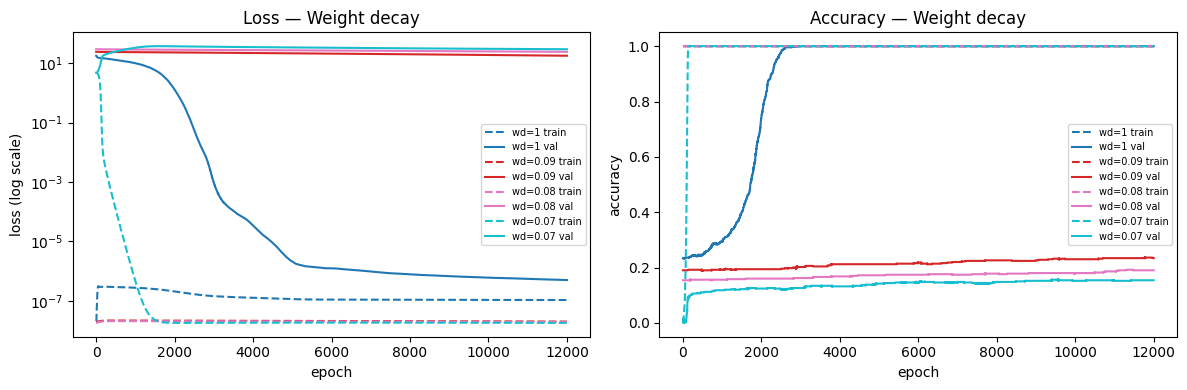

In [114]:
import os
import torch
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple
from mintrans_clean import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

files = os.listdir('./skeletons_var_lanbda')

path_wd = [{ "wd": decay.split('wd')[-1 :][0].split('_')[-1:][0].split('.pth')[0], "path": decay }for decay in files]


# ---------------------------------------------------------------------------
# Visualisation: loss / accuracy curves across different weight decay
# ---------------------------------------------------------------------------

def plot_training_curves_weight_decay(
    runs: List[Tuple[float, Dict]],  # (weight_decay, history)
    title: str = "",
) -> None:
    
    import matplotlib.pyplot as plt
    import matplotlib
    import numpy as np

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
    suffix = f" — {title}" if title else ""
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(runs)))

    for (wd, history), color in zip(runs, colors):
        epochs = range(1, len(history["train_loss"]) + 1)
        label = f"wd={wd}"

        ax_loss.semilogy(epochs, history["train_loss"], color=color, linestyle="--", label=f"{label} train")
        ax_loss.semilogy(epochs, history["val_loss"],   color=color, linestyle="-",  label=f"{label} val")

        ax_acc.plot(epochs, history["train_acc"], color=color, linestyle="--", label=f"{label} train")
        ax_acc.plot(epochs, history["val_acc"],   color=color, linestyle="-",  label=f"{label} val")

    ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("loss (log scale)")
    ax_loss.set_title(f"Loss{suffix}"); ax_loss.legend(fontsize=7)

    ax_acc.set_xlabel("epoch"); ax_acc.set_ylabel("accuracy")
    ax_acc.set_title(f"Accuracy{suffix}"); ax_acc.legend(fontsize=7)

    plt.tight_layout(); plt.show()

plot_data = []
for obj in path_wd:
    path = os.path.join("skeletons_var_lanbda", obj['path'])
    weight_decay = obj['wd']

    model = MinimalTransformer(
        vocab_size=cfg.vocab_size, d_model=cfg.d_model, n_heads=cfg.n_heads,
        num_layers=cfg.num_layers, max_seq_len=cfg.seq_len,
        hidden_mlp=cfg.hidden_mlp,
    ).to(device)

    skeletons = torch.load(path, map_location=device)

    plot_data.append((weight_decay, skeletons['history']))


plot_training_curves_weight_decay(plot_data, "Weight decay")